# 公式 o5 — Drosophila Circadian Clock（概日時計）

> **出典（E-Cell4 公式）**: Examples / example02 — https://ecell4.e-cell.org/examples/example02.html （Goldbeter 1995 の PER タンパク質モデル）
>
> 公式コードをそのまま移植（描画のみ matplotlib）。

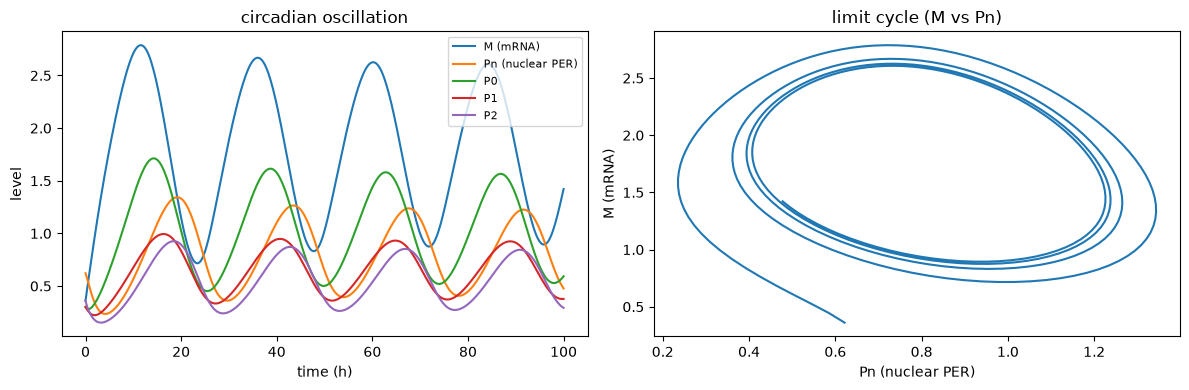

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

with reaction_rules():
    ~M > M | 0.76 / (1 + Pn ** 3)
    M > ~M | 0.65 * M / (0.5 + M)
    ~P0 > P0 | 0.38 * M
    P0 == P1 | (3.2 * P0 / (2 + P0), 1.58 * P1 / (2 + P1))
    P1 == P2 | (5 * P1 / (2 + P1), 2.5 * P2 / (2 + P2))
    P2 == Pn | (1.9, 1.3)
    P2 > ~P2 | 0.95 * P2 / (0.2 + P2)
m = get_model()
y0 = {'M': 0.361328202, 'Pn': 0.621367, 'P0': 0.301106835, 'P1': 0.301106835, 'P2': 0.361328202}
a = run_simulation(100, ndiv=400, model=m, y0=y0, species_list=['M','Pn','P0','P1','P2']).as_array()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for i, lab in enumerate(['M (mRNA)','Pn (nuclear PER)','P0','P1','P2'], 1):
    ax1.plot(a[:,0], a[:,i], label=lab)
ax1.set_xlabel('time (h)'); ax1.set_ylabel('level'); ax1.set_title('circadian oscillation'); ax1.legend(fontsize=8)
ax2.plot(a[:,2], a[:,1]); ax2.set_xlabel('Pn (nuclear PER)'); ax2.set_ylabel('M (mRNA)'); ax2.set_title('limit cycle (M vs Pn)')
plt.tight_layout(); plt.show()

## 読み取り

PER mRNA (M) と核内 PER (Pn) が**約24時間周期**で振動し、負フィードバック（核内 PER が自分の mRNA 転写を抑える）で
**リミットサイクル**（右図の閉軌道）を生む。概日リズムの古典的な反応速度論モデル。rate-law（Hill/Michaelis-Menten 型の式）を
反応速度に直接書けるのが要点。